# Mall Customer Segmentation — Data Cleaning & Feature Engineering

This dataset is exceptionally clean (200 rows, no missing values). The cleaning step reduces to one-hot encoding `Gender` and standardising all features so K-Means treats them on equal scales.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_data, preprocess_features
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Shape:', df.shape)
df.head()

Shape: (200, 4)


,Gender,Age,Income,SpendingScore
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## 2. Missing / Duplicate Check

In [3]:
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())

Missing: 0
Duplicates: 0


## 3. Encode Gender

In [4]:
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)
if 'Gender_Male' in df_encoded.columns:
    df_encoded['Gender_Male'] = df_encoded['Gender_Male'].astype(int)
df_encoded.head()

,Age,Income,SpendingScore,Gender_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


## 4. Standardise Features

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_cols = ['Age', 'Income', 'SpendingScore', 'Gender_Male']
X_scaled = scaler.fit_transform(df_encoded[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.describe().round(3)

,Age,Income,SpendingScore,Gender_Male
count,200.000,200.000,200.000,200.000
mean,-0.000,-0.000,-0.000,0.000
std,1.003,1.003,1.003,1.003
min,-1.496,-1.739,-1.910,-0.886
25%,-0.725,-0.728,-0.600,-0.886
50%,-0.205,0.036,-0.008,-0.886
75%,0.728,0.666,0.885,1.128
max,2.236,2.918,1.894,1.128


## 5. Compare Distributions Before vs After Scaling

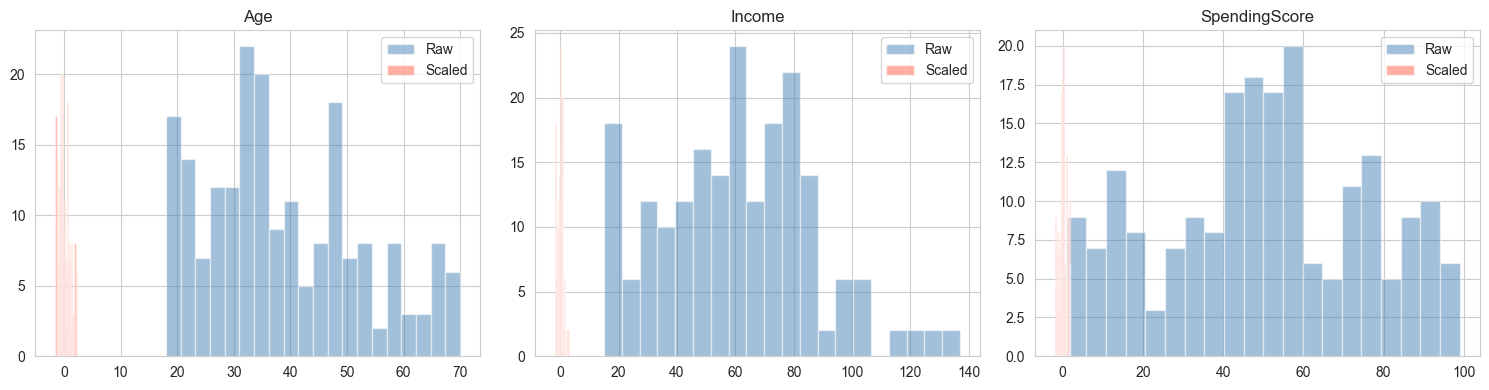

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Income', 'SpendingScore']):
    ax.hist(df_encoded[col], bins=20, alpha=0.5, label='Raw', color='steelblue')
    ax.hist(X_scaled_df[col], bins=20, alpha=0.5, label='Scaled', color='tomato')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## 6. Save Cleaned Dataset

In [7]:
df_encoded.to_csv('data/mall_customers_cleaned.csv', index=False)
X_scaled_df.to_csv('data/mall_customers_scaled.csv', index=False)
print('Saved -> data/mall_customers_cleaned.csv and data/mall_customers_scaled.csv')

Saved -> data/mall_customers_cleaned.csv and data/mall_customers_scaled.csv
